# Given the following prompts, create plots from the following:

1. Relationship between the Original Issue Year and the Effective Year
2. Median Effective Year as a function of County
3. Maximum Original Issue Year for the five most common counties as a function of Effective year.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("https://github.com/UIUC-iSchool-DataViz/is445_data/raw/main/licenses_fall2022.csv")
df

,_id,License Type,Description,License Number,License Status,Business,Title,First Name,Middle,Last Name,...,Specialty/Qualifier,Controlled Substance Schedule,Delegated Controlled Substance Schedule,Ever Disciplined,LastModifiedDate,Case Number,Action,Discipline Start Date,Discipline End Date,Discipline Reason
0,1189509,DETECTIVE BOARD,PERMANENT EMPLOYEE REGISTRATION,129446286,NOT RENEWED,N,NaN,EILEEN,NaN,SANTACRUZ,...,None,None,None,N,03/18/2022,None,None,None,None,None
1,801037,DETECTIVE BOARD,FIREARM CONTROL CARD,229030294.0,NOT RENEWED,N,NaN,DAGMAR,J,NORDLUND,...,None,None,None,N,08/16/2006,None,None,None,None,None
2,365129,COSMO,LICENSED COSMETOLOGIST,11053076.0,NOT RENEWED,N,NaN,RADOJE,NaN,ZELENOVIC,...,None,None,None,N,05/26/2006,None,None,None,None,None
3,595427,COSMO,LICENSED COSMETOLOGIST,11295645.0,ACTIVE,N,NaN,BECKY SUE,L,BURROUGHS,...,None,None,None,N,11/12/2021,None,None,None,None,None
4,653668,COSMO,LICENSED NAIL TECHNICIAN,169006247,NOT RENEWED,N,NaN,BILL G,L,LETNER,...,None,None,None,N,05/30/2006,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,888281,DETECTIVE BOARD,PERMANENT EMPLOYEE REGISTRATION,129002843.0,NOT RENEWED,N,NaN,JENNIFER,NaN,DARROW,...,None,None,None,N,08/03/2006,None,None,None,None,None
9996,766623,DETECTIVE BOARD,FIREARM CONTROL CARD,229014180,TERMINATED CARD RETURNED,N,NaN,BRYAN,NaN,WILLIAMS,...,None,None,None,N,08/07/2006,None,None,None,None,None
9997,399398,COSMO,LICENSED COSMETOLOGIST,11120249,NOT RENEWED,N,NaN,EUGENE,NaN,HENDERSON JR,...,None,None,None,N,05/26/2006,None,None,None,None,None
9998,486713,COSMO,LICENSED COSMETOLOGIST,11193270,ACTIVE,N,NaN,MAHLON DOUGLAS,NaN,CLIFT,...,None,None,None,N,12/17/2021,None,None,None,None,None


## 1. Relationship between the Original Issue Year and the Effective Year 

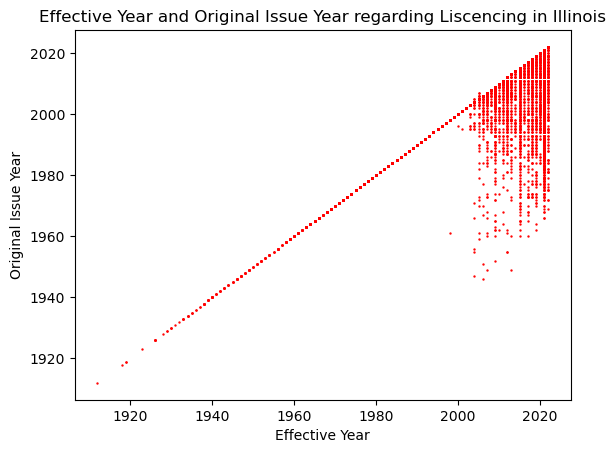

In [82]:
df['Original Issue Date'] = pd.to_datetime(df['Original Issue Date'],errors='coerce',format='%m/%d/%Y')
df['Original Issue Year'] = df['Original Issue Date'].dt.year

df['Effective Date'] = pd.to_datetime(df['Effective Date'],errors='coerce',format='%m/%d/%Y')
df['Effective Year'] = df['Effective Date'].dt.year

y = df['Original Issue Year']
x = df['Effective Year']

plt.scatter(x, y, color = 'red', s = 0.5)
plt.xlabel('Effective Year')
plt.ylabel('Original Issue Year')
plt.title('Effective Year and Original Issue Year regarding Liscencing in Illinois')
plt.show()

## 2. Median Effective Year as a function of County

In [5]:
df2 = df[['County', 'Effective Year']]
df2 = df2.sort_values(by = 'County', ascending = True)
df2 = df2.groupby('County').agg('Effective Year').median().reset_index()
df2['Effective Year']

0      2017.0
1      1993.0
2      1959.5
3      1994.0
4      1999.0
        ...  
136    2011.0
137    2010.0
138    1998.5
139    2008.0
140    2015.0
Name: Effective Year, Length: 141, dtype: float64

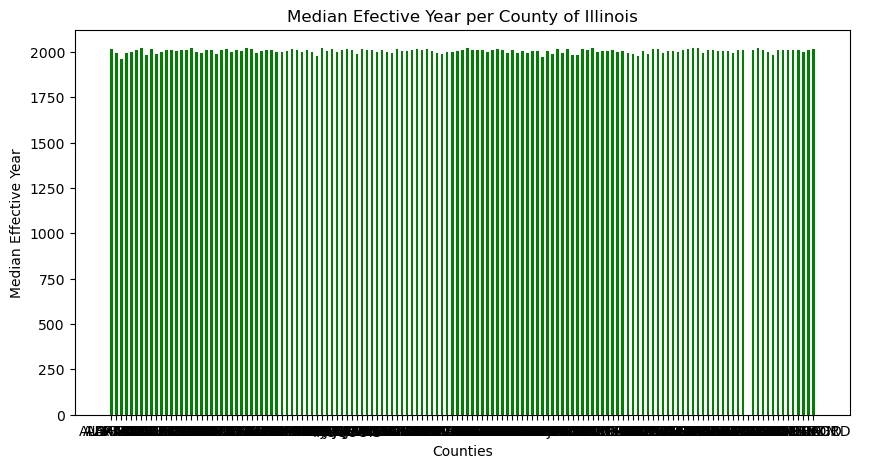

In [71]:
xa = df2['County']
ya = df2['Effective Year']
fig = plt.figure(figsize = (10, 5))
mey_plt = plt.bar(xa, ya, color = 'green', width = 0.5)
plt.xlabel("Counties")
plt.ylabel("Median Effective Year")
plt.title("Median Efective Year per County of Illinois")
plt.show()

## 3. Maximum Original Issue Year for the five most common counties as a function of Effective year. 

### Create data frame by county to find most popular:

In [38]:
df['Effective Year'].astype(str)
df['Original Issue Year'].astype(str)
df4 = df[['County', 'Effective Year', 'Original Issue Year']]
df4_mc = df4.groupby('County').agg('count').reset_index()
df4_mc = df4_mc.sort_values(by = 'Original Issue Year', ascending = False)
df4_mc.head(5)

,County,Effective Year,Original Issue Year
19,COOK,4459,4742
25,DUPAGE,495,533
135,WILL,378,398
61,LAKE,347,367
54,KANE,249,258


### Create individual data frames:

In [53]:
df_cook = df4[df4["County"] == "COOK"]
df_cook = df_cook.sort_values(by = 'Original Issue Year', ascending = False)
df_cook = df_cook.dropna()
df_cook

,County,Effective Year,Original Issue Year
4952,COOK,2022.0,2022.0
3875,COOK,2022.0,2022.0
3768,COOK,2022.0,2022.0
6249,COOK,2022.0,2022.0
3720,COOK,2022.0,2022.0
...,...,...,...
6747,COOK,1928.0,1928.0
520,COOK,1926.0,1926.0
120,COOK,1923.0,1923.0
6203,COOK,1919.0,1919.0


In [54]:
df_dp = df4[df4["County"] == "DUPAGE"]
df_dp = df_dp.sort_values(by = 'Original Issue Year', ascending = False)
df_dp = df_dp.dropna()
df_dp

,County,Effective Year,Original Issue Year
9391,DUPAGE,2022.0,2022.0
824,DUPAGE,2022.0,2022.0
8723,DUPAGE,2021.0,2021.0
7270,DUPAGE,2021.0,2021.0
1620,DUPAGE,2021.0,2021.0
...,...,...,...
5945,DUPAGE,1955.0,1955.0
1807,DUPAGE,1946.0,1946.0
16,DUPAGE,1939.0,1939.0
6596,DUPAGE,1938.0,1938.0


In [55]:
df_w = df4[df4["County"] == "WILL"]
df_w = df_w.sort_values(by = 'Original Issue Year', ascending = False)
df_w = df_w.dropna()
df_w

,County,Effective Year,Original Issue Year
2826,WILL,2022.0,2022.0
5686,WILL,2022.0,2022.0
1164,WILL,2021.0,2021.0
3016,WILL,2021.0,2021.0
2162,WILL,2021.0,2021.0
...,...,...,...
3365,WILL,1969.0,1969.0
4147,WILL,1967.0,1967.0
9869,WILL,1961.0,1961.0
6919,WILL,2005.0,1961.0


In [56]:
df_l = df4[df4["County"] == "LAKE"]
df_l = df_cook.sort_values(by = 'Original Issue Year', ascending = False)
df_l = df_l.dropna()
df_l

,County,Effective Year,Original Issue Year
4952,COOK,2022.0,2022.0
7450,COOK,2022.0,2022.0
2176,COOK,2022.0,2022.0
2266,COOK,2022.0,2022.0
395,COOK,2022.0,2022.0
...,...,...,...
6747,COOK,1928.0,1928.0
520,COOK,1926.0,1926.0
120,COOK,1923.0,1923.0
6203,COOK,1919.0,1919.0


In [57]:
df_k = df4[df4["County"] == "KANE"]
df_k = df_k.sort_values(by = 'Original Issue Year', ascending = False)
df_k = df_k.dropna()
df_k

,County,Effective Year,Original Issue Year
9981,KANE,2022.0,2022.0
961,KANE,2022.0,2022.0
7957,KANE,2022.0,2022.0
7231,KANE,2022.0,2022.0
9778,KANE,2021.0,2021.0
...,...,...,...
4080,KANE,1971.0,1971.0
8939,KANE,2005.0,1970.0
6489,KANE,2011.0,1968.0
6532,KANE,2009.0,1962.0


### Create line graph:

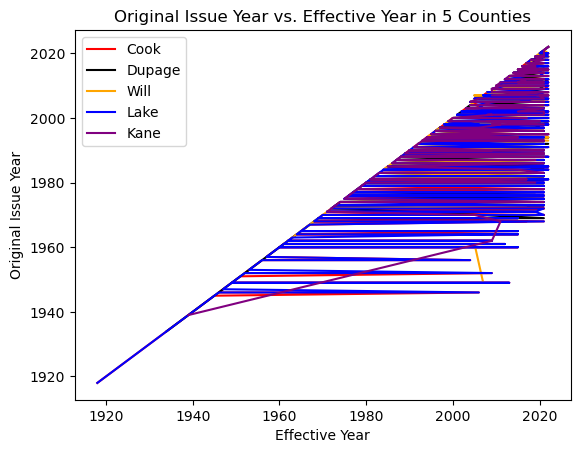

In [69]:
xa1 = df_cook['Effective Year']
ya1 = df_cook['Original Issue Year']

xa2 = df_dp['Effective Year']
ya2 = df_dp['Original Issue Year']

xa3 = df_w['Effective Year']
ya3 = df_w['Original Issue Year']

xa4 = df_l['Effective Year']
ya4 = df_l['Original Issue Year']

xa5 = df_k['Effective Year']
ya5 = df_k['Original Issue Year']

plt.plot(xa1, ya1, label = 'Cook', color = 'red')
plt.plot(xa2, ya2, label = 'Dupage', color = 'black')
plt.plot(xa3, ya3, label = 'Will', color = 'orange')
plt.plot(xa4, ya4, label = 'Lake', color = 'blue')
plt.plot(xa5, ya5, label = 'Kane', color = 'purple')
plt.xlabel("Effective Year")
plt.ylabel("Original Issue Year")
plt.title("Original Issue Year vs. Effective Year in 5 Counties")
plt.legend()
plt.show()

## Write Up

For this assignement, the following prompts were used:

1. Relationship between the Original Issue Year and the Effective Year
2. Median Effective Year as a function of County
3. Maximum Original Issue Year for the five most common counties as a function of Effective year

The assignment looks at the Illinois Licensing Dataset and attempts to analyze said data set via the following prompts (which are all related to the Effective year and Original Issue Year.

Prompt #1:
    Since the prompt is looking into the relationship of the 2 years, the best plot to use would be the scatter plot (and of the 3, this was the easiest to do). To generate the plot, 2 additional columns were created so that the given dates became years and then with Effective Years as the X-axis and the Original Issue Years as the Y-axis, a plot was generated. The size of the data points chosen were size 0.5 so as to clearly display each point and somewhat prresevee the true vaue of the data. A random color for the data was chosen for the data. Analyzing the generated plot, from 1960 till 2000, the relationship of the points seem linear but beyond 2000, the shape of the data changed drastically, which indicated there may have been a change(possibbly in legislation or some event) sometime at the start of the 21st century. Regarding the relationship of the correlations,there seems to be a somewhat strong positive correlation.

Prompt #2:
    The way I attempted this promt was to group the data by county and then aggregate the data by the effective year and further aggregate it it by looking for the median yer per county and a bargraph was used to display the data. Due to the large amount of counties present in the data frame, a very large bar graph should be made so as to see the county names. There also is a gap in the data due to displaced data. However from the bargraph, the average median year can be approximated as the 1980's.
    Regarding the execution of my thoughts, i orginally intended to do a scatter as each point represented the county, and the x represented the median effective year and the y is frequency. After consideration though, a bar would have made more sense because scatter plots were typically used to find correlations and there was no correlations that was required.

Prompt #3:
    Admittedly, this was the most dificult to do. It required several steps (shown by the sub headings under the prompt) from organizing the data frame, to dividing the data frame into smaller dataframes and then generating a line graph. I had a difficult time writing the code for this prompt because i felt that I may be over think how to est execute the way I want to solve this prompt since I was complicating the data y contiuous grouping and sorting but seemed to be loosing data in the process. It was only after a finally rewrite I decided to execute the method above.
     The generated graph looks mostly linear but since the 5 counties (Cook, Dupage, Will, Lake, and Kane) all overlap, it's difficult to discern somegraphs versus others, for example, it's easier to see Lake compared to Kane. Speaking of Lake, the line generated formed a strange triangular shape. Like what happened in Prompt #1, the idea there was some event that occured to cause this shape is suspect.
 